<a href="https://colab.research.google.com/github/nagapandi1982/Colab-projects/blob/main/KNNAlgorith_Attrition_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#2. can you predict the employee attrition in an organization based on the following features. The features and the dataset are given below. use a classification model with KNN algorithm
#Features:
#Age: Age of the employee (numerical).
#JobRole: The job role/position of the employee (categorical).
#MonthlyIncome: Employee's monthly salary (numerical).
#JobSatisfaction: A rating from 1 to 4 indicating the employee's satisfaction with the job (numerical).
#YearsAtCompany: Number of years the employee has been at the company (numerical).
#Attrition: Target label indicating whether the employee left the company (1 for attrition, 0 for noattrition)

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [5]:
# Sample data for training (Age,JobRole,MonthlyIncome,JobSatisfaction,YearsAtCompany,Attrition: 1=attrition, 0=No-attrition)
data = { 'Age': [29, 35, 40, 28, 45, 25, 50, 30, 37, 26],'MonthlyIncome': [4800, 6000, 3400, 4300, 11000, 3500, 12000, 5000, 3100, 4500],'JobSatisfaction': [3, 4, 2, 3, 4, 1, 4, 2, 2, 3],'YearsAtCompany': [4, 8, 6, 3, 15, 2, 20, 5, 9, 2],'Attrition': [1, 0, 0, 1, 0, 1, 0, 0, 0, 1] }
# Convert data to DataFrame
# data = pd.read_csv("/content/sample_data/bankloan_classification_train.csv")

In [6]:
data = pd.DataFrame(data)
# Split features and labels
# Separate features (X) and labels (y)
X = data.iloc[:, :-1].values  # All columns except the last one are features
y = data.iloc[:, -1].values   # The last column is the target (Outcome: 0 or 1)

In [8]:
print (X)
print (y)

[[   29  4800     3     4]
 [   35  6000     4     8]
 [   40  3400     2     6]
 [   28  4300     3     3]
 [   45 11000     4    15]
 [   25  3500     1     2]
 [   50 12000     4    20]
 [   30  5000     2     5]
 [   37  3100     2     9]
 [   26  4500     3     2]]
[1 0 0 1 0 1 0 0 0 1]


In [20]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (normalize the age and loan_amount)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


[[2]]


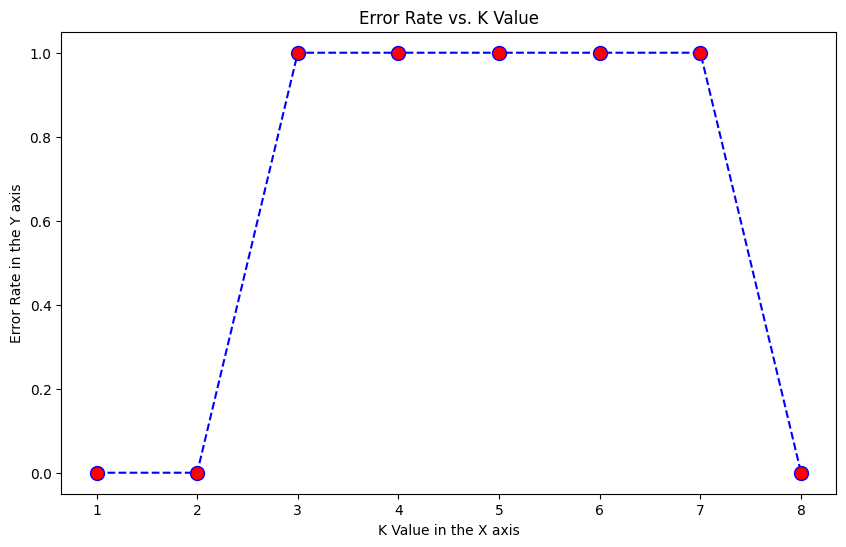

WITH K=1


[[2]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [21]:

## Using KNN
#Remember that we are trying to come up with a model to predict whether someone
#will TARGET CLASS or not. We'll start with k=1.

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=1, p=2,
           weights='uniform')

pred = knn.predict(X_test)

#Predicting and evavluations
#Let's evaluate our knn model.

print(confusion_matrix(y_test,pred))

#Choosing a K Value

#Let's go ahead and use the elbow method to pick a good K Value:

error_rate = []

# Will take some time

# Corrected the range to len(X_train) to avoid n_neighbors exceeding n_samples_fit
for i in range(1, len(X_train) + 1):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1, len(X_train) + 1),error_rate,color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value in the X axis')
plt.ylabel('Error Rate in the Y axis')
plt.show()

#Here we can see that that after arouns K>23 the error rate just tends to hover
#around 0.06-0.05 Let's retrain the model with that and check the classification report!

# FIRST A QUICK COMPARISON TO OUR ORIGINAL K=1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

In [19]:
# NOW WITH K=2
knn = KNeighborsClassifier(n_neighbors=2)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=2')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=2


[[2]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [22]:
# Predict for 3 new samples
# New customer samples (Age, MonthlyIncome, JobSatisfaction, YearsAtCompany)
# The new_customers array must also have 4 features to match the model's input
new_customers = np.array([[28, 6000, 3, 5], [50, 17000, 4, 10], [38, 11000, 2, 8]])

# Scale the new customer data
new_customers_scaled = scaler.transform(new_customers)

# Predict whether they will repay or default
predictions = model.predict(new_customers_scaled)

# Print predictions (1 = repay, 0 = default)
for i, prediction in enumerate(predictions):
    print(f"Customer {i + 1}: {'Attrition' if prediction >= 0.5 else 'Noattrition'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Customer 1: Attrition
Customer 2: Noattrition
Customer 3: Noattrition
